# Notebook 4: Functional Annotation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import leaves_list
from collections import Counter
from gprofiler import GProfiler
import os

In [24]:
# Load outputs from previous notebooks
data    = pd.read_csv('outputs/data_imputed.tsv', sep='\t', index_col=0)
modules = pd.read_csv('outputs/module_assignments.tsv', sep='\t')
nodes   = pd.read_csv('outputs/network_nodes.tsv', sep='\t')  # includes degree (connectivity)

In [25]:
print("DATA SUMMARY")
print("Expression data:", data.shape[0], "proteins X", data.shape[1], "patients\n")

print("Proteins assigned to modules:", len(modules))
print("Number of detected modules:", modules["module_id"].nunique(),"\n")

print("PROTEINS PER MODULE")
module_sizes = (modules.groupby("module_id").size().sort_values(ascending=False))

print(module_sizes)

DATA SUMMARY
Expression data: 10164 proteins X 118 patients

Proteins assigned to modules: 449
Number of detected modules: 14 

PROTEINS PER MODULE
module_id
0     116
1      96
2      95
3      47
4      24
5      19
6      16
7       8
8       7
9       6
10      5
11      5
12      3
13      2
dtype: int64


## STEP 1: MODULE EIGENGENES

In [26]:
eigengenes = {}

for module_id in sorted(modules["module_id"].unique()):
    # get proteins belonging to this module
    proteins_in_module = modules[modules["module_id"] == module_id]['protein'].tolist()
    # keep only proteins present in expression data
    proteins_in_module = [protein for protein in proteins_in_module if protein in data.index]
    
    if len(proteins_in_module) >= 3:  # only include modules with at least 3 proteins
        # calculate average expression of module proteins per patient
        eigengenes[f'Module_{module_id}'] = data.loc[proteins_in_module].mean(axis=0)

eigengene_df = pd.DataFrame(eigengenes)

In [27]:
eigengene_df.head()

,Module_0,Module_1,Module_2,Module_3,Module_4,Module_5,Module_6,Module_7,Module_8,Module_9,Module_10,Module_11,Module_12
Patient_1,0.302683,0.113919,0.287059,0.366670,0.347396,0.180946,0.400024,0.387208,0.217631,0.273030,0.294063,0.199904,0.226626
Patient_2,-0.156811,-0.371353,-0.110875,-0.190722,-0.282702,-0.007986,-0.169952,-0.361692,-0.031515,-0.100007,-0.029601,-0.186853,-0.080074
Patient_3,-0.039396,-0.186771,0.031693,-0.157643,-0.155274,0.001218,-0.013541,-0.069716,0.067227,0.019351,0.026109,0.117784,0.066389
Patient_4,-0.062370,-0.295985,-0.090733,-0.202263,-0.172074,-0.010156,-0.157633,-0.168642,-0.161759,-0.105246,-0.251248,-0.007180,-0.153069
Patient_5,-0.344254,-0.419654,-0.360138,-0.323200,-0.387860,-0.123165,-0.377896,-0.516409,-0.333629,-0.170049,-0.558531,-0.311380,-0.277216


In [28]:
eigengene_df.shape

(118, 13)

## STEP 2: HEATMAP

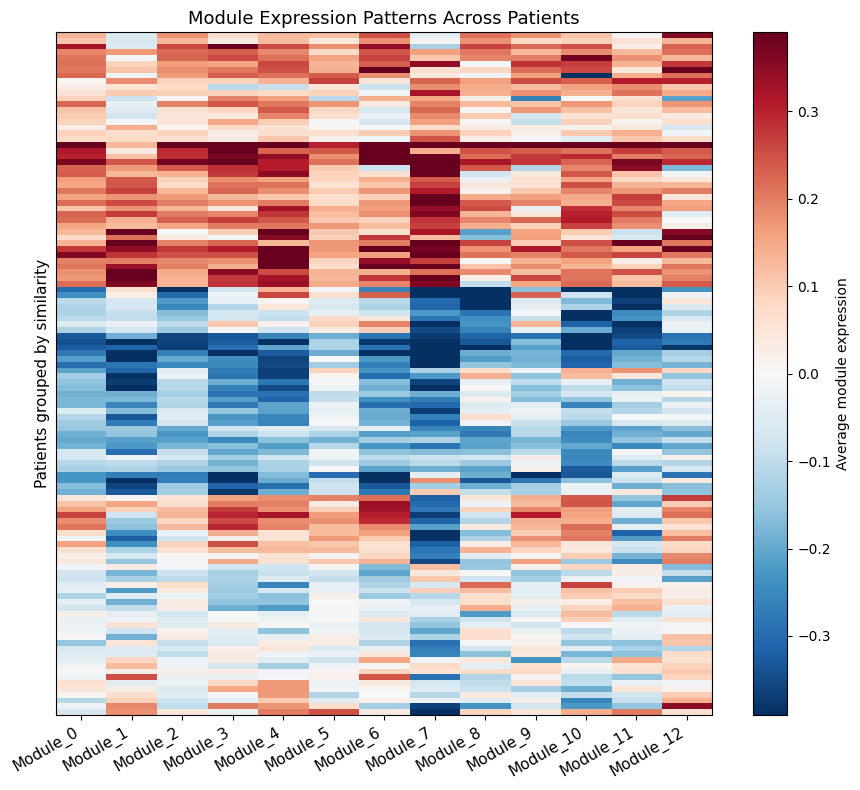

In [29]:
# group similar patients together based on module expression patterns
linkage_matrix = linkage(eigengene_df.values, method="ward")

# get new patient ordering
patient_order = leaves_list(linkage_matrix)

# rearrange patients using the clustering order
eigengene_clustered = eigengene_df.iloc[patient_order]

# create heatmap
fig, ax = plt.subplots(figsize=(9, 8))

# reduce effect of extreme values on colors
color_range = np.percentile(np.abs(eigengene_clustered.values),95)

heatmap = ax.imshow(
    eigengene_clustered.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-color_range,
    vmax=color_range
)

# show module names on x-axis
ax.set_xticks(range(eigengene_df.shape[1]))
ax.set_xticklabels(eigengene_df.columns, rotation=30, ha="right", fontsize=11)

ax.set_ylabel("Patients grouped by similarity", fontsize=11)
ax.set_yticks([])

ax.set_title("Module Expression Patterns Across Patients", fontsize=13)

# add color scale
plt.colorbar(heatmap,ax=ax,label="Average module expression")
plt.tight_layout()

plt.savefig("outputs/figures/eigengene_heatmap.png",dpi=150)

plt.show()

## STEP 3: DECIDING NUMBER OF CLUSTERS

In [30]:
# standardize module activity so all modules contribute equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(eigengene_df)

# try different cluster counts
k_values = range(2, 7)
silhouette_scores = {}

print("Testing patient clustering (KMeans)\n")
print("K\tSilhouette score")
print("-" * 25)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores[k] = score

    print(k, "\t", round(score, 4))

# pick best number of clusters
best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)
print("\nBest K:", best_k)
print("Best silhouette:", round(silhouette_scores[best_k], 4))

Testing patient clustering (KMeans)

K	Silhouette score
-------------------------
2 	 0.374
3 	 0.2764
4 	 0.2555
5 	 0.2424
6 	 0.2328

Best K: 2
Best silhouette: 0.374


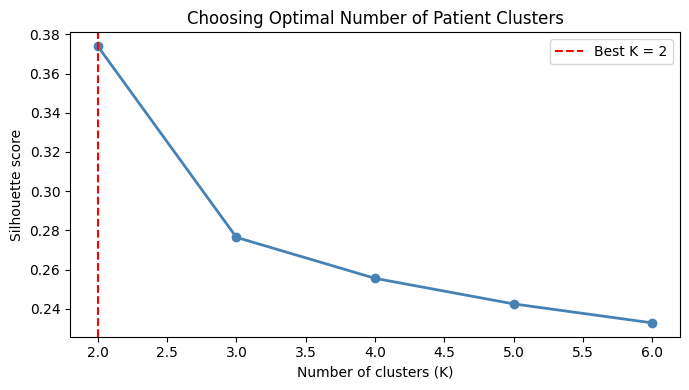

In [31]:
plt.figure(figsize=(7, 4))

plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o", color="steelblue", linewidth=2)

plt.axvline(best_k, color="red", linestyle="--", label=f"Best K = {best_k}")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score")
plt.title("Choosing Optimal Number of Patient Clusters")

plt.legend()

plt.tight_layout()

plt.savefig("outputs/figures/silhouette_scores.png", dpi=150)

plt.show()

## STEP 4: CLUSTERING PATIENTS

In [32]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X_scaled)

eigengene_df["patient_cluster"] = cluster_labels
patient_cluster_df = pd.DataFrame({"patient": eigengene_df.index, "cluster": cluster_labels})

patient_cluster_df.to_csv("outputs/patient_clusters.tsv", sep="\t", index=False)

print("Patient cluster sizes:")
cluster_counts = Counter(cluster_labels)

for cid in sorted(cluster_counts): 
    print(f"Cluster {cid}: {cluster_counts[cid]} patients")

print("\nTotal patients:", len(cluster_labels))

Patient cluster sizes:
Cluster 0: 53 patients
Cluster 1: 65 patients

Total patients: 118


In [33]:
module_cols = [c for c in eigengene_df.columns if c.startswith('Module_')]
cluster_means = eigengene_df.groupby('patient_cluster')[module_cols].mean()

print('Average module activity across patient clusters:')
print(cluster_means.round(3).to_string())

Average module activity across patient clusters:
                 Module_0  Module_1  Module_2  Module_3  Module_4  Module_5  Module_6  Module_7  Module_8  Module_9  Module_10  Module_11  Module_12
patient_cluster                                                                                                                                     
0                   0.171     0.126     0.148     0.195     0.227     0.122     0.175     0.163     0.099     0.139      0.164      0.115      0.159
1                  -0.108    -0.143    -0.112    -0.119    -0.103    -0.034    -0.107    -0.207    -0.116    -0.066     -0.131     -0.120     -0.043


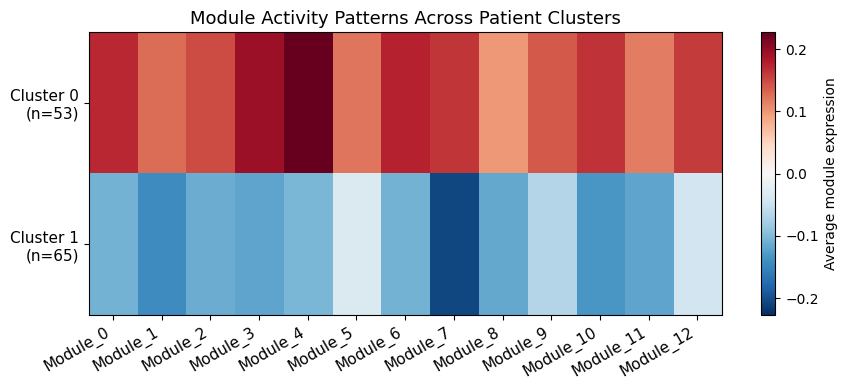

In [34]:
# Heatmap showing how modules behave across patient clusters
fig, ax = plt.subplots(figsize=(9, 4))

# Use same color scale for both high and low values
color_limit = np.max(np.abs(cluster_means.values))

heatmap = ax.imshow(
    cluster_means.values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-color_limit,
    vmax=color_limit
)

# X-axis = modules
ax.set_xticks(range(len(module_cols)))
ax.set_xticklabels(module_cols, rotation=30, ha="right", fontsize=11)

# Y-axis = patient clusters
ax.set_yticks(range(best_k))
ax.set_yticklabels(
    [f"Cluster {i}\n(n={cluster_counts[i]})" for i in range(best_k)],
    fontsize=11
)

ax.set_title("Module Activity Patterns Across Patient Clusters", fontsize=13)
plt.colorbar(heatmap, ax=ax, label="Average module expression")
plt.tight_layout()
plt.savefig("outputs/figures/cluster_module_heatmap.png", dpi=150)
plt.show()

## STEP 5: FUNCTIONAL ANNOTATION

In [35]:
# build module-level summaries: size, hub proteins, and full gene list
module_info = {}

print("MODULE SUMMARIES")
print("(Top hub proteins are the highly connected proteins in full network)\n")

# combine module assignment with node degree information
module_table = modules.merge(
    nodes[["protein", "degree"]],
    on="protein",
    how="left"
)

# process each module separately
for module_id in sorted(modules["module_id"].unique()):
    current_module = module_table[module_table["module_id"] == module_id].sort_values("degree", ascending=False)

    protein_list = current_module["protein"].tolist()
    hub_proteins = protein_list[:10]

    module_info[module_id] = {
        "size": len(protein_list),
        "top_hubs": hub_proteins,
        "all_proteins": protein_list
    }

    print(f"Module {module_id} ({len(protein_list):,} proteins)")
    print("Top hubs:", ", ".join(hub_proteins[:7]))
    print("")

MODULE SUMMARIES
(Top hub proteins are the highly connected proteins in full network)

Module 0 (116 proteins)
Top hubs: DDX17, U2AF2, ACTL6A, NCL, SNRNP70, KHDRBS1, SNRPA1

Module 1 (96 proteins)
Top hubs: NIFK, PDCD11, NOL6, MPHOSPH10, RCL1, DDX27, DDX10

Module 2 (95 proteins)
Top hubs: SF3B2, YLPM1, CDC5L, SF3A3, THRAP3, SRSF6, IK

Module 3 (47 proteins)
Top hubs: CHD4, SMARCA2, KDM1A, SMARCC2, SMARCE1, SMARCD2, SMARCB1

Module 4 (24 proteins)
Top hubs: NOP56, NOP58, FAM98B, GAR1, DDX1, FBL, DKC1

Module 5 (19 proteins)
Top hubs: SNRNP200, DDX23, SYMPK, PRPF8, MED24, EFTUD2, PRPF6

Module 6 (16 proteins)
Top hubs: POLR1B, POLR1A, POLR3D, POLR3A, TWISTNB, POLR1E, POLR1C

Module 7 (8 proteins)
Top hubs: ALYREF, CHTOP, LLPH, ZRANB2, C11orf98, CCDC137, TAF3

Module 8 (7 proteins)
Top hubs: NUP153, SCAF8, SON, ZC3H14, RBM14, PCF11, SRRM2

Module 9 (6 proteins)
Top hubs: THOC5, THOC2, THOC7, THOC1, MTA2, THOC6

Module 10 (5 proteins)
Top hubs: MED10, MED8, TAF10, MED29, MED22

Module 11 

## STEP 5: GO ENRICHMENT

In [36]:
gp_client = GProfiler(return_dataframe=True)

# use detected proteins as background (not full genome)
reference_set = data.index.tolist()
enrichment_outputs = {}

for module_id in sorted(module_info.keys()):
    genes = module_info[module_id]["all_proteins"]

    print(f"Enrichment analysis for Module {module_id} ({len(genes):,} proteins)...")
    try:
        enrichment_df = gp_client.profile(
            organism="hsapiens",
            query=genes,
            background=reference_set,
            sources=["GO:BP", "GO:MF", "KEGG", "REAC"],
            significance_threshold_method="fdr",
            no_evidences=True
        )

        enrichment_outputs[module_id] = enrichment_df

        if len(enrichment_df) > 0:
            significant_hits = (enrichment_df["p_value"] < 0.05).sum()
        else:
            significant_hits = 0
        print("  Significant terms:", significant_hits)

    except Exception as err:
        print("  Error during enrichment:", err)
        enrichment_outputs[module_id] = pd.DataFrame()

print("\nEnrichment step completed.")

Enrichment analysis for Module 0 (116 proteins)...
  Significant terms: 310
Enrichment analysis for Module 1 (96 proteins)...
  Significant terms: 71
Enrichment analysis for Module 2 (95 proteins)...
  Significant terms: 185
Enrichment analysis for Module 3 (47 proteins)...
  Significant terms: 399
Enrichment analysis for Module 4 (24 proteins)...
  Significant terms: 96
Enrichment analysis for Module 5 (19 proteins)...
  Significant terms: 125
Enrichment analysis for Module 6 (16 proteins)...
  Significant terms: 106
Enrichment analysis for Module 7 (8 proteins)...
  Significant terms: 5
Enrichment analysis for Module 8 (7 proteins)...
  Significant terms: 45
Enrichment analysis for Module 9 (6 proteins)...
  Significant terms: 54
Enrichment analysis for Module 10 (5 proteins)...
  Significant terms: 103
Enrichment analysis for Module 11 (5 proteins)...
  Significant terms: 31
Enrichment analysis for Module 12 (3 proteins)...
  Significant terms: 69
Enrichment analysis for Module 13 (

In [37]:
enrichment_outputs[0].head()

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:BP,GO:0141187,nucleic acid biosynthetic process,6.134772e-32,True,"""The biosynthetic process resulting in the for...",2724,113,93,9981,0.823009,0.034141,query_1,"[GO:0009059, GO:0034654, GO:0090304]"
1,GO:BP,GO:0016071,mRNA metabolic process,6.134772e-32,True,"""The chemical reactions and pathways involving...",618,113,53,9981,0.469027,0.085761,query_1,[GO:0016070]
2,GO:BP,GO:0016070,RNA metabolic process,6.134772e-32,True,"""The cellular chemical reactions and pathways ...",2778,113,94,9981,0.831858,0.033837,query_1,[GO:0090304]
3,GO:BP,GO:0006397,mRNA processing,6.134772e-32,True,"""Any process involved in the conversion of a p...",427,113,47,9981,0.415929,0.110070,query_1,"[GO:0006396, GO:0016071]"
4,GO:BP,GO:0032774,RNA biosynthetic process,6.134772e-32,True,"""The chemical reactions and pathways resulting...",2636,113,92,9981,0.814159,0.034901,query_1,"[GO:0016070, GO:0141187]"


In [38]:
# print('\nAUTOMATIC MODULE ANNOTATION\n')

# module_annotations = {}

# for mod_id in sorted(module_summaries.keys()):
#     print(f'Module {mod_id}')

#     info = module_summaries[mod_id]

#     print(f'Size: {info["size"]:,} proteins')
#     print(f'Top hub proteins: {", ".join(info["top_hubs"][:10])}')
#     print()

#     # Get enrichment results
#     if mod_id in enrichment_outputs:
#         result = enrichment_outputs[mod_id]

#         if len(result) > 0:
#             # Sort by significance
#             result = result.sort_values('p_value')

#             # Keep only strongest unique biological terms
#             top_terms = (
#                 result[['source', 'name', 'p_value']]
#                 .drop_duplicates(subset='name')
#                 .head(10)
#             )

#             print('Top enriched biological terms:')

#             for _, row in top_terms.iterrows():
#                 print(
#                     f'  [{row["source"]}] '
#                     f'{row["name"]} '
#                     f'(p={row["p_value"]:.2e})'
#                 )

#             # Save for later report usage
#             module_annotations[mod_id] = {
#                 'top_terms': top_terms['name'].tolist(),
#                 'hub_proteins': info['top_hubs']
#             }

#         else:
#             print('No significant enrichment terms found.')

#     else:
#         print('No enrichment results available.')

#     print('\n')

In [39]:
# import gseapy as gp

# msigdb_results = {}

# for module_id in module_info.keys():
#     genes = module_info[module_id]["all_proteins"]
#     try:
#         enr = gp.enrichr(
#             gene_list=genes,
#             gene_sets="MSigDB_Hallmark_2020",
#             organism="Human",
#             outdir=None
#         )

#         msigdb_results[module_id] = enr.results

#     except Exception:
#         msigdb_results[module_id] = pd.DataFrame()

In [40]:
# msigdb_results[0].head()

In [41]:
module_names = {}

for module_id in module_info.keys():
    msigdb_df = msigdb_results.get(module_id, pd.DataFrame())
    go_df = enrichment_outputs.get(module_id, pd.DataFrame())

    final_name = None

    # # trying MSigDB
    # if len(msigdb_df) > 0:
    #     print("Using MSigDB")
    #     top_term = msigdb_df.sort_values(
    #         "Adjusted P-value"
    #     )["Term"].iloc[0]

    #     final_name = top_term.replace("HALLMARK_", "").replace("_", " ").title()

    # # fallback to GO terms
    # elif len(go_df) > 0:
    #     print("Using GO Terms")
    #     top_term = go_df.sort_values("p_value")["name"].iloc[0]
    #     final_name = top_term
    if len(go_df) > 0:
        top_term = go_df.sort_values("p_value")["name"].iloc[0]
        final_name = top_term
    else:
        final_name = f"Uncharacterized Module {module_id}"
    module_names[module_id] = final_name

In [42]:
print("\nFINAL MODULE ANNOTATION\n")
for module_id in sorted(module_info.keys()):
    print(f"Module {module_id}")
    print(f"Name: {module_names[module_id]}")
    print(f"Size: {module_info[module_id]['size']:,} proteins")
    print(f"Top hubs: {', '.join(module_info[module_id]['top_hubs'][:5])}")
    print("-" * 50)


FINAL MODULE ANNOTATION

Module 0
Name: nucleic acid biosynthetic process
Size: 116 proteins
Top hubs: DDX17, U2AF2, ACTL6A, NCL, SNRNP70
--------------------------------------------------
Module 1
Name: ribosome biogenesis
Size: 96 proteins
Top hubs: NIFK, PDCD11, NOL6, MPHOSPH10, RCL1
--------------------------------------------------
Module 2
Name: mRNA processing
Size: 95 proteins
Top hubs: SF3B2, YLPM1, CDC5L, SF3A3, THRAP3
--------------------------------------------------
Module 3
Name: Regulation of endogenous retroelements
Size: 47 proteins
Top hubs: CHD4, SMARCA2, KDM1A, SMARCC2, SMARCE1
--------------------------------------------------
Module 4
Name: rRNA processing in the nucleus and cytosol
Size: 24 proteins
Top hubs: NOP56, NOP58, FAM98B, GAR1, DDX1
--------------------------------------------------
Module 5
Name: Processing of Capped Intron-Containing Pre-mRNA
Size: 19 proteins
Top hubs: SNRNP200, DDX23, SYMPK, PRPF8, MED24
---------------------------------------------

In [43]:
print("PATIENT CLUSTER INTERPRETATION\n")

for cid in sorted(cluster_counts.keys()):
    cluster_profile = cluster_means.loc[cid].sort_values(ascending=False)

    top_modules = cluster_profile.head(2).index.tolist()
    bottom_modules = cluster_profile.tail(2).index.tolist()

    print(f"Cluster {cid} (n = {cluster_counts[cid]} patients)")

    print("  Most active modules:")
    for m in top_modules:
        print(f"    - {m}: {module_names.get(int(m.split('_')[1]), 'Unknown')}")

    print("  Least active modules:")
    for m in bottom_modules:
        print(f"    - {m}: {module_names.get(int(m.split('_')[1]), 'Unknown')}\n")


PATIENT CLUSTER INTERPRETATION

Cluster 0 (n = 53 patients)
  Most active modules:
    - Module_4: rRNA processing in the nucleus and cytosol
    - Module_3: Regulation of endogenous retroelements
  Least active modules:
    - Module_11: mRNA Splicing - Major Pathway
    - Module_8: mRNA binding

Cluster 1 (n = 65 patients)
  Most active modules:
    - Module_5: Processing of Capped Intron-Containing Pre-mRNA
    - Module_12: Nucleocytoplasmic transport
  Least active modules:
    - Module_1: ribosome biogenesis
    - Module_7: RNA binding

